# Imports and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/saygineralper/nokta-dataset/nokta.csv")
df.head()

,p1,p2
0,14.541182,9.171020
1,15.066288,7.708681
2,12.784097,9.935294
3,11.746347,9.769397
4,5.807864,14.875203


# Model

In [3]:
from sklearn.cluster import DBSCAN

In [4]:
dbscan = DBSCAN()

<Axes: xlabel='p1', ylabel='p2'>

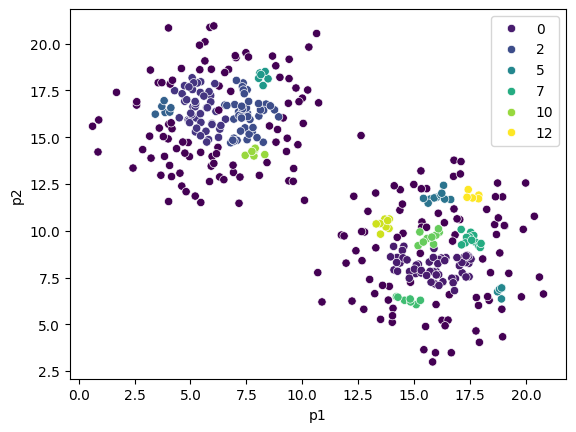

In [5]:
label = dbscan.fit_predict(df)

sns.scatterplot(x="p1", y="p2", data=df, hue=label, palette="viridis")

In [6]:
np.unique(label)
# -1: Value given for outliers.

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [7]:
dbscan.labels_[:30]

array([ 0,  0, -1, -1,  1, -1,  0, -1, -1, -1, -1, -1, 11,  2,  2,  1, -1,
       -1, -1, -1,  2,  5, -1, -1,  3,  0, -1, 10,  2,  2])

In [8]:
# # of outliers.
sum(dbscan.labels_ == -1)

np.int64(182)

In [9]:
def kume(model, data):
    label = model.fit_predict(data)

    sns.scatterplot(x="p1", y="p2", data=data, hue=label, palette="viridis")
    print("Count of Outliers: ", sum(dbscan.labels_ == -1))

# Examining DBSCAN Model With Various Epsilon Parameters

Count of Outliers:  1


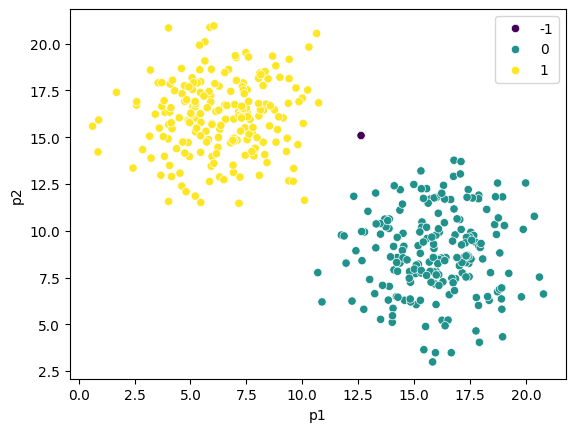

In [10]:
# For eps = 2
dbscan = DBSCAN(eps=2)
kume(dbscan,df)

Count of Outliers:  400


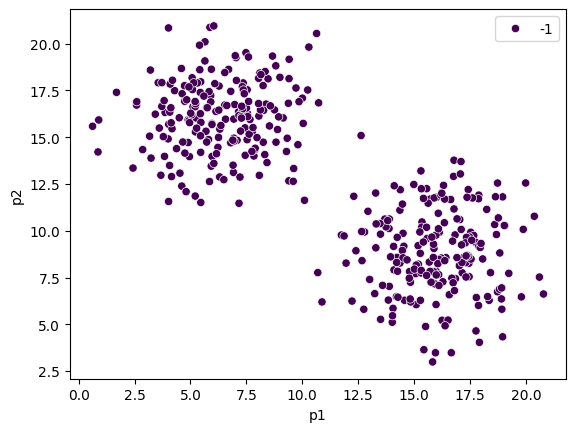

In [11]:
# For eps = 0.1
dbscan = DBSCAN(eps=0.1)
kume(dbscan,df)

Count of Outliers:  0


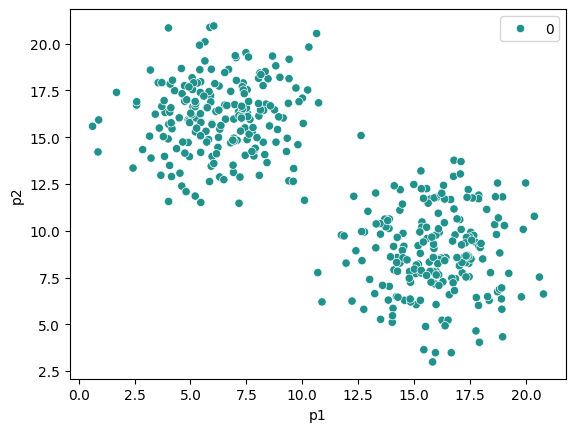

In [12]:
# For eps = 10
dbscan = DBSCAN(eps=10)
kume(dbscan,df)

# Choosing Best Epsilon Value Wrt Desired # of Outliers

In [13]:
# Finding the epsilon value wrt the desired number of outliers
yuzde_deger = []
num_outlier = []

for eps in np.arange(0.01,4,0.01):

    dbscan = DBSCAN(eps=eps)
    dbscan.fit(df)

    num_outlier.append(np.sum(dbscan.labels_ == -1))

    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)

    yuzde_deger.append(perc_outliers)

Text(0.5, 0, 'Epsilon')

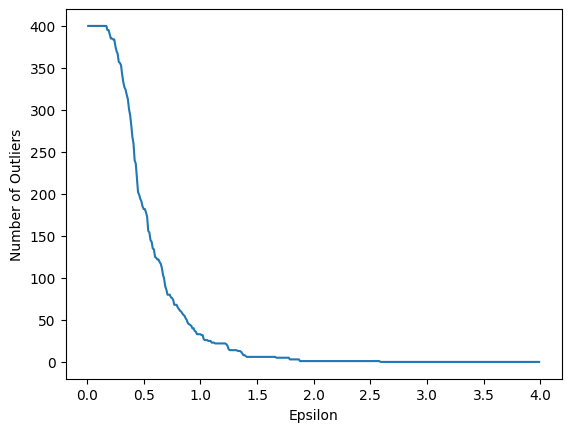

In [14]:
sns.lineplot(x=np.arange(0.01,4,0.01), y=num_outlier)
plt.ylabel("Number of Outliers")
plt.xlabel("Epsilon")

Text(0.5, 0, 'Epsilon')

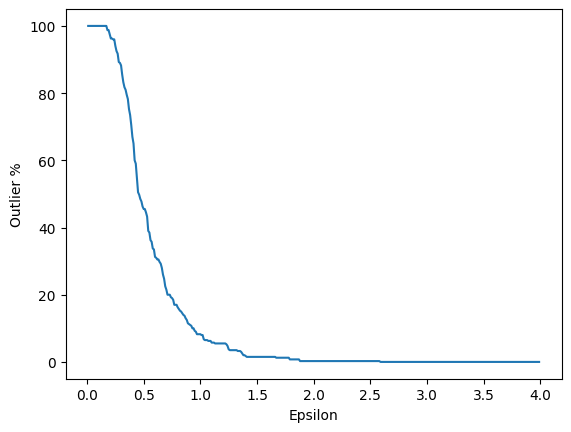

In [15]:
sns.lineplot(x=np.arange(0.01,4,0.01),y=yuzde_deger)
plt.ylabel("Outlier %")
plt.xlabel("Epsilon")

# Determining Number of Outliers

(1.2, 2.0)

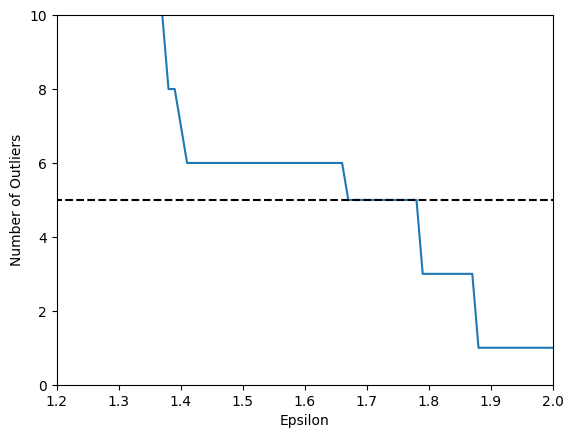

In [16]:
sns.lineplot(x= np.arange(0.01,4,0.01), y=num_outlier)
plt.ylabel("Number of Outliers")
plt.xlabel("Epsilon")

plt.hlines(y=5, xmin=0, xmax=4, colors="black", ls="--")
plt.ylim(0,10)
plt.xlim(1.2,2)

# 5 outliers is desired

Count of Outliers:  5


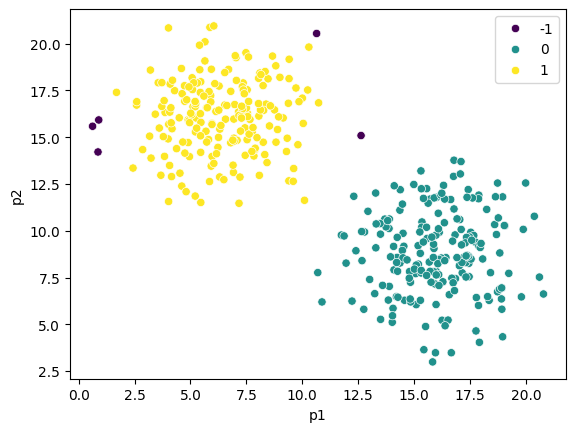

In [17]:
dbscan= DBSCAN(eps=1.7)
kume(dbscan, df)

(0.9, 1.1)

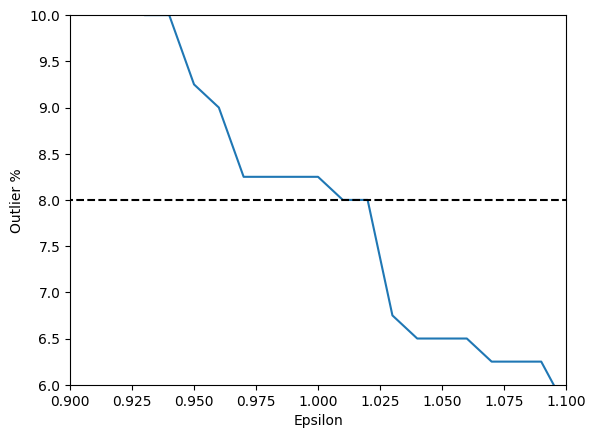

In [18]:
sns.lineplot(x=np.arange(0.01,4,0.01),y=yuzde_deger)
plt.ylabel("Outlier %")
plt.xlabel("Epsilon")

plt.hlines(y=8, xmin=0, xmax=4, colors="black", ls="--")
plt.ylim(6,10)
plt.xlim(0.9,1.1)
# 8 % of outliers is desired

Count of Outliers:  32


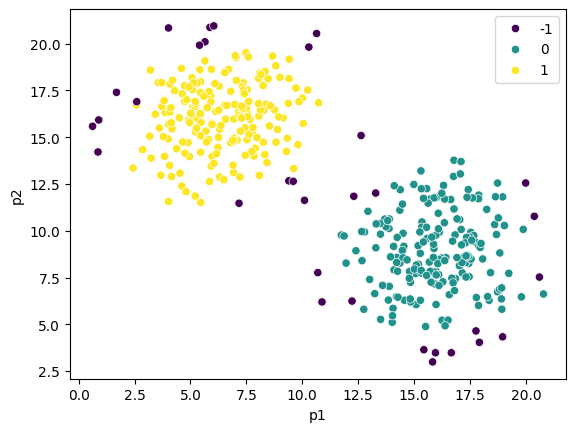

In [19]:
dbscan= DBSCAN(eps=1.01)
kume(dbscan, df)

In [20]:
32/400 * 100

8.0

In [21]:
# In DBSCAN algorithm the eps parameter determines the "neighborhood" radius of a data point and directly affects clustering performance. There is an inverse correlation between the choice of this value and the number of outliers (outs) determined.